# Modeling Airbnb Listing Prices in Vancouver

#### DSCI 310 Sec 101, Group 01
#### Jialin Zhang, Richard He, Sean Holiday, Eddi Xie

## 0. Summary

A total of 4,621 Airbnb listings throughout Vancouver, Canada were analysed to determine which of their respective features were most strongly associated with rental pricing. The report utilises Exploratory Data Analysis (EDA) and a multiple linear regression model on a log scale to take outliers into account. 

## 1. Introduction

Airbnb is a company that acts as a middleman between homeowners and tourists through providing the former a platform to use their property as vacation rentals. 

The dataset used for this research project was detailed Airbnb listings data in Vancouver. This dataset held many features that detailed each listing in the city concerning the host (ex. response rate, superhost status), the property (ex. room type, neighbourhood, # of bedrooms), and the pricings. There are in total 79 features throughout this dataset and 5,685 rows. 

Many of these features are associated with the listing prices, however only some are expected to have strong links to them. After identifying and selecting features with the most association, can they be used to predict the nightly price of any Airbnb listing in Vancouver?

Research Question:
**Can we predict the nightly price of Airbnb listings in Vancouver, British Columbia using key hosting and property features?**

## 2. Methods and Results

### 2.1 Data Cleaning and Processing

In [1]:
library(tidyverse)
library(repr)
library(ggplot2)
library(dplyr)
library(readr)
library(stringr)
library(patchwork)
library(car)
library(broom)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.6
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.1     v tibble    3.3.0
v lubridate 1.9.4     v tidyr     1.3.2
v purrr     1.2.0     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: carData


Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode


The following object is masked from 'package:purrr':

    some




In [2]:
# Import the dataset
url = "https://data.insideairbnb.com/canada/bc/vancouver/2025-11-17/data/listings.csv.gz"
raw_airbnb <- read_csv(url)

# Uncomment if desired to load df locally
# raw_airbnb <- read.csv("data/raw/listings.csv")

Rows: 5685 Columns: 79
-- Column specification --------------------------------------------------------
Delimiter: ","
chr  (25): listing_url, source, name, description, neighborhood_overview, pi...
dbl  (42): id, scrape_id, host_id, host_listings_count, host_total_listings_...
lgl   (7): host_is_superhost, host_has_profile_pic, host_identity_verified, ...
date  (5): last_scraped, host_since, calendar_last_scraped, first_review, la...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
# Set a random seed to ensure reproducibility
set.seed(310)

# Keep the target variable and most relevant columns
# Keep 'id' as a character variable
# Remove rows where 'price' is empty, and transfer 'price' into a numeric variable
airbnb <- raw_airbnb %>%
  select(
    id, host_is_superhost, neighbourhood_cleansed, property_type, room_type, 
    accommodates, bathrooms, bedrooms, price, review_scores_rating, reviews_per_month
  ) %>%
  mutate(id = as.character(id)) %>%
  filter(!is.na(price), price != "") %>%
  mutate(
    price = price %>%
      str_remove_all("[$,]") %>%
      as.numeric()
  ) %>%
  filter(!is.na(price)) %>%
  # Explicitly drop rows with missing values in your model's predictors
  drop_na(accommodates, bedrooms, bathrooms, room_type, property_type)

In [4]:
# Refactor 'host_is_superhost' to 'Yes', 'No', "Unknown'
airbnb <- airbnb %>%
  mutate(
    host_is_superhost = case_when(
      host_is_superhost == TRUE ~ "Yes",
      host_is_superhost == FALSE ~ "No",
      is.na(host_is_superhost) ~ "Unknown",
      TRUE ~ "Unknown"
    ),
    host_is_superhost = as.factor(host_is_superhost)
  )

In [5]:
# Check the number of unique property types and neighbourhood
length(unique(airbnb$property_type))
length(unique(airbnb$neighbourhood_cleansed))

[1] 42

[1] 23

Since the number of unique property types and neighbourhoods is large, including all categories may reduce model stability and interpretability. Therefore, we merge less frequent property types and neighbourhoods into a single category labelled “Other”.

In [6]:
# Find out the 4 most frequent property types
top4_property <- airbnb %>%
  count(property_type, sort = TRUE) %>%
  slice_head(n = 4) %>%
  pull(property_type)

# Merge the remaining values into "Other"
airbnb <- airbnb %>%
  mutate(property_type = ifelse(property_type %in% top4_property,
                                property_type,
                                "Other"),
         property_type = as.factor(property_type))

In [7]:
# Find out the 4 most frequent neighbourhoods
top4_neighbourhoods <- airbnb %>%
  count(neighbourhood_cleansed, sort = TRUE) %>%
  slice_head(n = 4) %>%
  pull(neighbourhood_cleansed)

# Merge the remaining values into "Other" and rename the column
airbnb <- airbnb %>%
  mutate(neighbourhood = ifelse(neighbourhood_cleansed %in% top4_neighbourhoods,
                                neighbourhood_cleansed,
                                "Other"),
         neighbourhood = as.factor(neighbourhood))

In [8]:
head(airbnb)

id,host_is_superhost,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,price,review_scores_rating,reviews_per_month,neighbourhood
<chr>,<fct>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
13188,Yes,Riley Park,Other,Entire home/apt,4,1,0,136,4.85,1.99,Other
13358,Yes,Downtown,Entire condo,Entire home/apt,2,1,1,188,4.71,3.11,Downtown
18270,No,Mount Pleasant,Other,Private room,2,1,1,47,4.54,0.66,Mount Pleasant
18589,Yes,Grandview-Woodland,Private room in home,Private room,2,1,1,123,4.98,3.60,Other
18795,No,West End,Private room in home,Private room,2,1,1,75,4.56,0.74,Other
20085,No,Kensington-Cedar Cottage,Other,Entire home/apt,3,1,2,90,4.80,0.42,Other


### 2.2 Train-Test Split

In [9]:
airbnb_train <- airbnb %>% 
    dplyr::sample_frac(0.8)

airbnb_test <- dplyr::anti_join(airbnb, airbnb_train, by = 'id')

cat("Training Set Dimensions:", dim(airbnb_train), "\n")
cat("Testing Set Dimensions:", dim(airbnb_test), "\n")

Training Set Dimensions: 3690 12 
Testing Set Dimensions: 922 12 


The train-test split for the dataframe is 80-20. The splitting is necessary to prevent any data leakage in future model creation steps. 

### 2.3 Exploratory Data Analysis

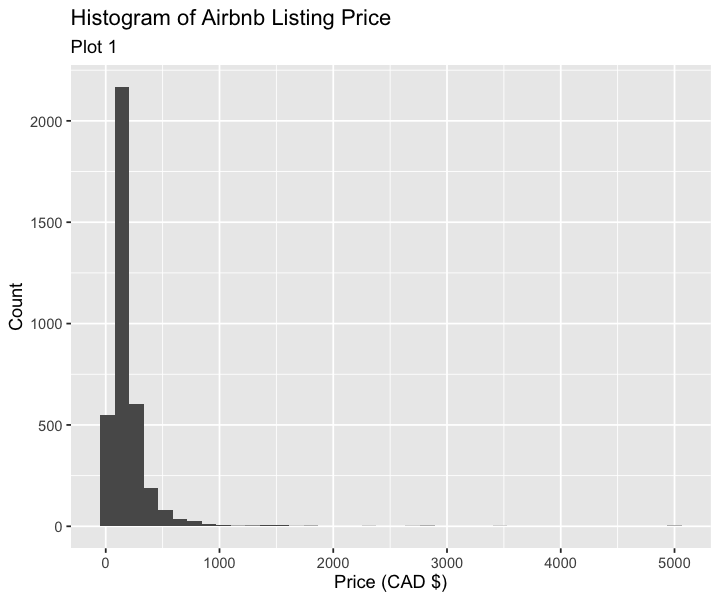

In [10]:
options(repr.plot.width = 6, repr.plot.height = 5)

# Plot a histogram of 'price'
p1 <- ggplot(airbnb_train, aes(x = price)) + 
  geom_histogram(bins = 40) + 
  labs(title = "Histogram of Airbnb Listing Price", 
       x = "Price (CAD $)", y = "Count", subtitle = "Plot 1")

p1

Since the distribution of `price` is extremely right-skewed, we apply a log transformation and use **log-transformed price** `log_price` in the regression analysis to improve normality and stabilize variance.

In [11]:
# Create a column called 'log_price'
airbnb_train <- airbnb_train %>%
  mutate(log_price = log(price))

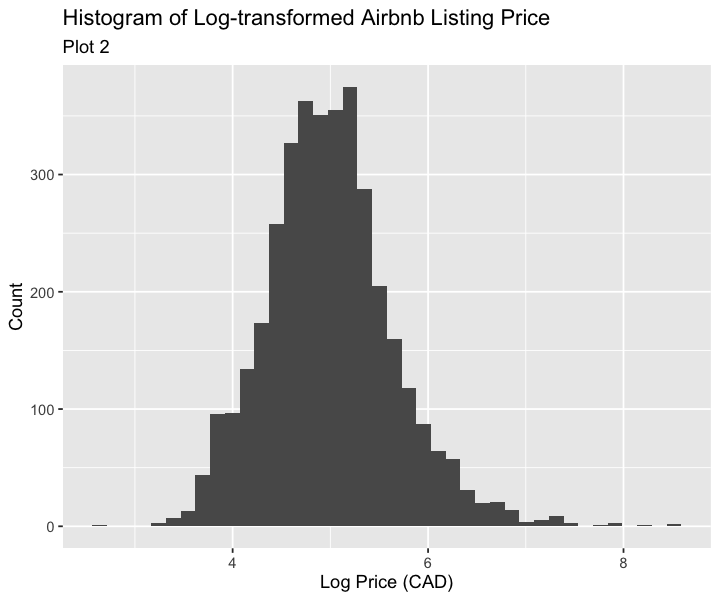

In [12]:
options(repr.plot.width = 6, repr.plot.height = 5)

# Plot a histogram of 'log_price'
p2 <- ggplot(airbnb_train, aes(x = log_price)) + 
  geom_histogram(bins = 40) + 
  labs(title = "Histogram of Log-transformed Airbnb Listing Price", 
       x = "Log Price (CAD)", y = "Count", subtitle = "Plot 2")

p2

We will conduct an exploratory data analysis (EDA) to identify the variables that are most strongly associated with `log_price`. These variables are then selected as predictors in the multiple linear regression model.

In [13]:
# Also creating a log_price target variable for our test data

airbnb_test <- airbnb_test %>% 
    mutate(log_price = log(price))

#### 2.3.1 Analyze Numeric Variables

In [14]:
# Select numeric variables
numeric_vars <- airbnb_train %>%
  select(log_price, accommodates, bathrooms, bedrooms,
         review_scores_rating, reviews_per_month)

# Compute the correlation between log_price and numeric predictors
cor(numeric_vars, use = "complete.obs")["log_price", ] %>%
  enframe(name = "variable", value = "correlation") %>%
  filter(variable != "log_price") %>%
  arrange(desc(abs(correlation)))

variable,correlation
<chr>,<dbl>
accommodates,0.57707491
bedrooms,0.54801919
bathrooms,0.52915414
review_scores_rating,0.16625540
reviews_per_month,-0.03228619


The table shows the Pearson correlation coefficients between `log_price` and the numeric predictors. Variables such as `accommodates`, `bedrooms` and `bathrooms` show **moderately strong correlations**, as their coefficients are larger than 0.5. Variables such as `review_scores_rating` and `reviews_per_month` with very small absolute correlations show **no linear relationship** with `log_price`.

#### 2.3.2 Analyzing Categorical Variables

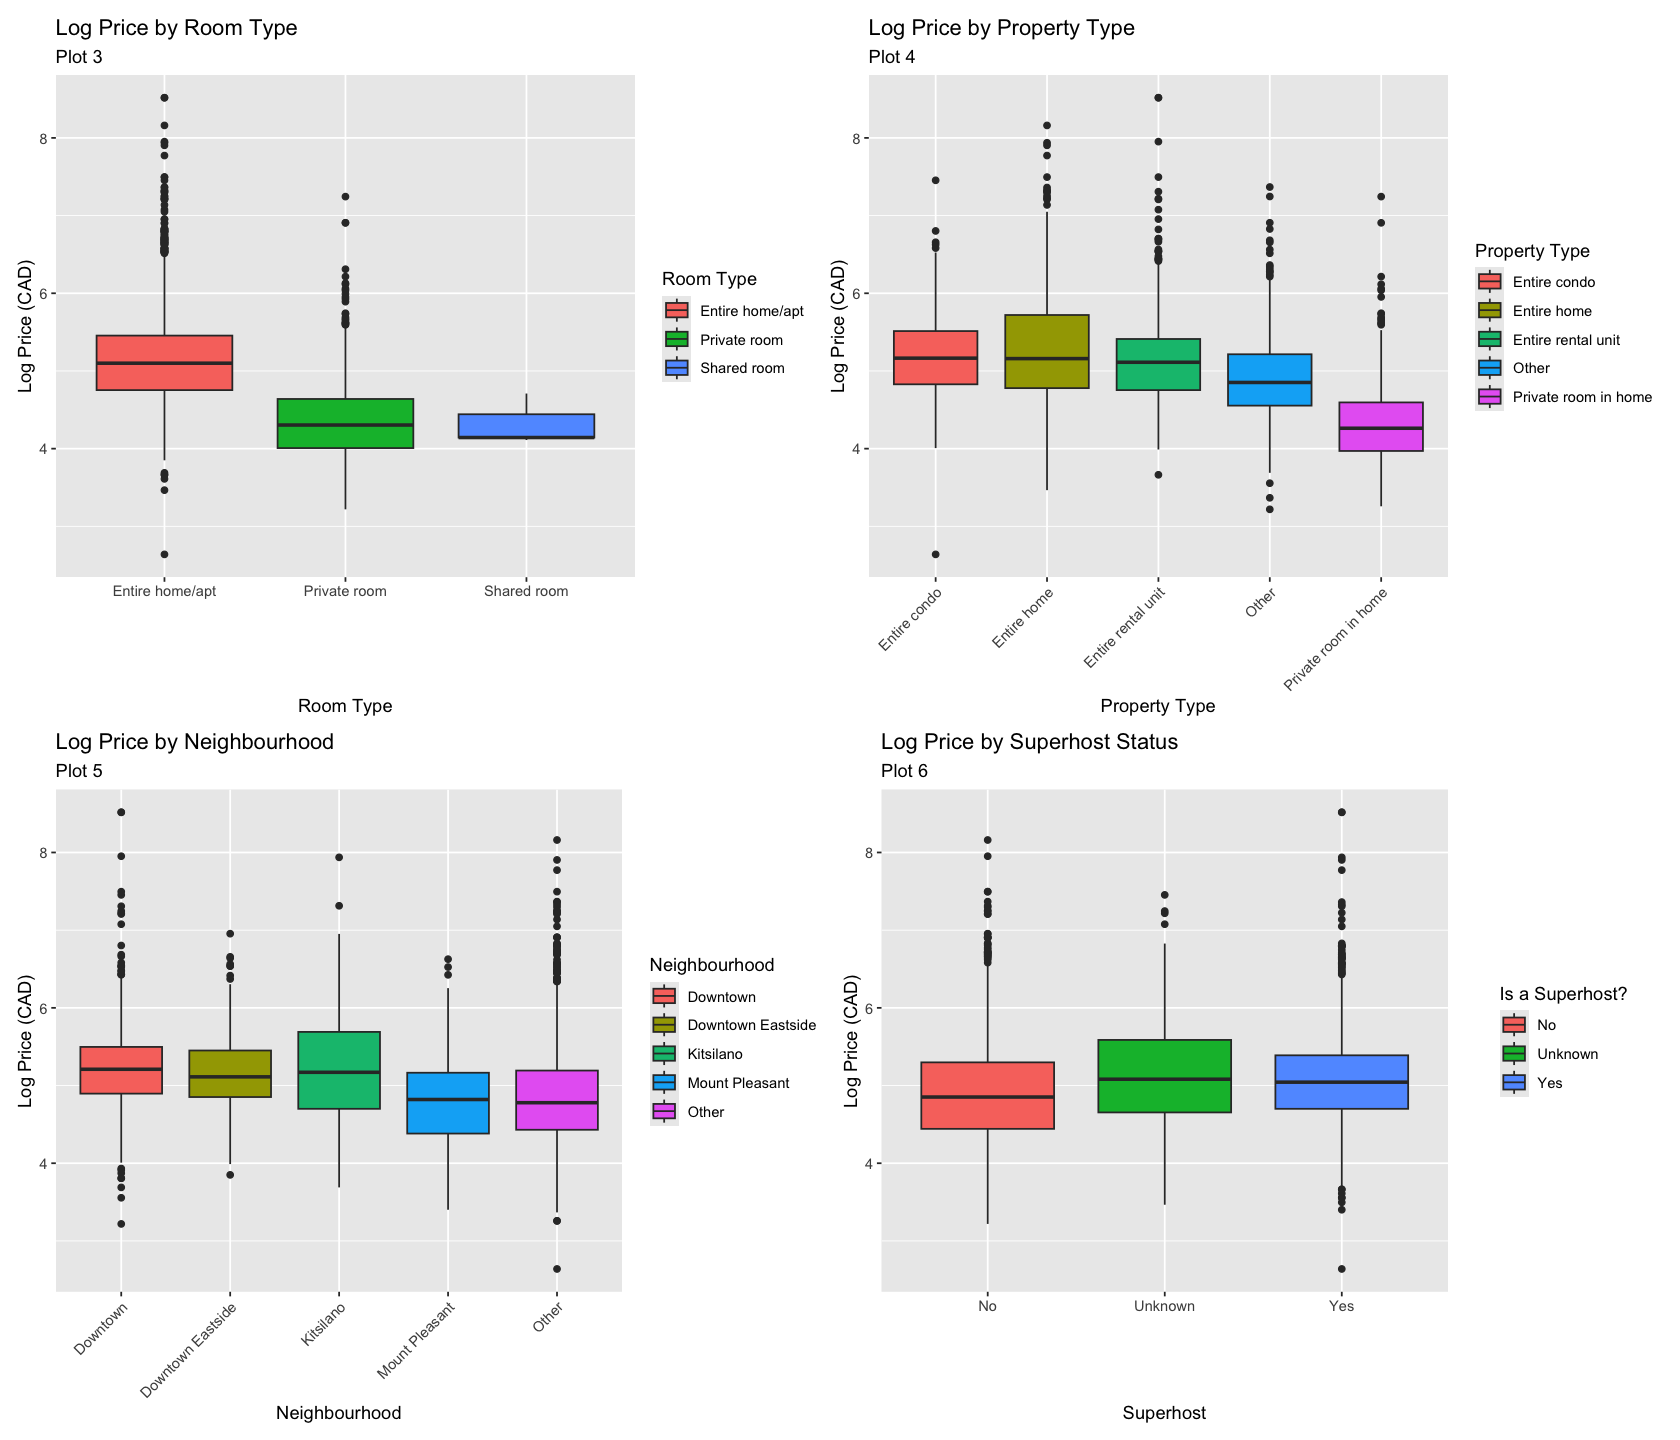

In [15]:
options(repr.plot.width = 14, repr.plot.height = 12)

# Boxplot: Room Type vs. Log Price
p3 <- ggplot(airbnb_train, aes(x = room_type, y = log_price, fill = room_type)) +
  geom_boxplot() +
  labs(title = "Log Price by Room Type",
       x = "Room Type",
       y = "Log Price (CAD)",
       fill = "Room Type",
       subtitle = "Plot 3")

# Boxplot: Property Type vs. Log Price
p4 <- ggplot(airbnb_train, aes(x = property_type, y = log_price, fill = property_type)) +
  geom_boxplot() +
  labs(title = "Log Price by Property Type",
       x = "Property Type",
       y = "Log Price (CAD)",
       fill = "Property Type",
       subtitle = "Plot 4") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Boxplot: Neighbourhood vs. Log Price
p5 <- ggplot(airbnb_train, aes(x = neighbourhood, y = log_price, fill = neighbourhood)) +
  geom_boxplot() +
  labs(title = "Log Price by Neighbourhood",
       x = "Neighbourhood",
       y = "Log Price (CAD)",
       fill = "Neighbourhood",
       subtitle = "Plot 5") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Boxplot: Superhost Status vs. Log Price
p6 <- ggplot(airbnb_train, aes(x = host_is_superhost, y = log_price, fill = host_is_superhost)) +
  geom_boxplot() +
  labs(title = "Log Price by Superhost Status",
       x = "Superhost",
       y = "Log Price (CAD)",
       fill = "Is a Superhost?", 
       subtitle = "Plot 6")

(p3 | p4) / (p5 | p6)

The boxplots illustrate the relationship between `log_price` and four categorical variables. Plot 3 shows clear difference in log price range and median log prices across different room types, with entire homes having higher prices than private or shared rooms. Plot 4 also shows clear differences in median log prices across different property types. In contrast, Plot 5 and Plot 6 show more overlap among groups. Therefore, `room_type` and `property_type` **appear to be stronger predictors of** `log_price` and are more suitable to be included in the regression model.

### 2.4 Check Multicollinearity

Based on the exploratory data analysis, we initially selected five variables (`bathrooms`, `accommodates`, `bedrooms`, `room_type`, and `property_type`) as potential predictors of `log_price`. Before finalizing the model, we need to conduct a **Variance Inflation Factor (VIF) analysis to check multicollinearity**, which refers to the situation where predictor variables are highly correlated with one another, inflate standard errors and reduce model stability. 

In [16]:
# Build a test model using accommodates, bedrooms, bathrooms, room_type and property_type for multicollinearity check
model_vif <- lm(
  log_price ~ accommodates + bedrooms + bathrooms + room_type + property_type,
  data = airbnb_train
)

# Find out the VIF value for each variable
vif(model_vif) %>%
  as.data.frame() %>%
  select(`GVIF^(1/(2*Df))`) %>%
  rename(VIF = `GVIF^(1/(2*Df))`) %>%
  tibble::rownames_to_column("Variable")

Variable,VIF
<chr>,<dbl>
accommodates,1.972958
bedrooms,2.069212
bathrooms,1.481691
room_type,1.476599
property_type,1.232791


The VIF result shows that all the variables have VIF values below 5, indicating low levels of multicollinearity. Therefore, we will use all five variables in the final multiple linear regression model.

### 2.5 Modeling

In [17]:
# Build the multiple linear regression model using accommodates, bedrooms, bathrooms, room_type and property_type
airbnb_model <- lm(
    log_price ~ accommodates + bedrooms + bathrooms + room_type + property_type, 
    data = airbnb_train
)

print(airbnb_model)


Call:
lm(formula = log_price ~ accommodates + bedrooms + bathrooms + 
    room_type + property_type, data = airbnb_train)

Coefficients:
                      (Intercept)                       accommodates  
                          4.49950                            0.05375  
                         bedrooms                          bathrooms  
                          0.09789                            0.27468  
            room_typePrivate room               room_typeShared room  
                         -0.34728                           -0.39548  
         property_typeEntire home    property_typeEntire rental unit  
                         -0.20821                           -0.06724  
               property_typeOther  property_typePrivate room in home  
                         -0.15028                           -0.34242  



The estimated multiple linear regression model is:

**log_price = 4.49950 + 0.05375 * accommodates + 0.09789 * bedrooms + 0.27468 * bathrooms - 0.34728 * PrivateRoom - 0.39548 * SharedRoom - 0.20821 * EntireHome - 0.06724 * EntireRentalUnit - 0.15028 * Other - 0.34242 * PrivateRoomInHome**

### 2.6 Prediction 

In [23]:
predictions <- predict(airbnb_model, newdata = airbnb_test)

actuals <- airbnb_test$log_price

#RMSE
rmse <- sqrt(mean((predictions - actuals)^2))

#r2
ss_res <- sum((actuals - predictions)^2)
ss_tot <- sum((actuals - mean(actuals))^2)
r2_test <- 1 - (ss_res / ss_tot)

print(paste0("Test RMSE: ", rmse))
print(paste0("Test R-squared: ", r2_test))

[1] "Test RMSE: 0.460254180543878"
[1] "Test R-squared: 0.496507374384843"


## 3. Discussion

### 3.1 Interpreting and Evaluating the Model

In [27]:
summary(airbnb_model)


Call:
lm(formula = log_price ~ accommodates + bedrooms + bathrooms + 
    room_type + property_type, data = airbnb_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.82056 -0.31776 -0.03146  0.26306  2.95437 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        4.49950    0.02700 166.624  < 2e-16 ***
accommodates                       0.05375    0.00737   7.293 3.70e-13 ***
bedrooms                           0.09789    0.01691   5.790 7.64e-09 ***
bathrooms                          0.27468    0.01693  16.225  < 2e-16 ***
room_typePrivate room             -0.34728    0.04137  -8.395  < 2e-16 ***
room_typeShared room              -0.39548    0.14259  -2.773  0.00557 ** 
property_typeEntire home          -0.20821    0.02765  -7.529 6.40e-14 ***
property_typeEntire rental unit   -0.06724    0.02522  -2.667  0.00770 ** 
property_typeOther                -0.15028    0.02770  -5.425 6.17e-08 ***
property

`height` was translated to `width`.


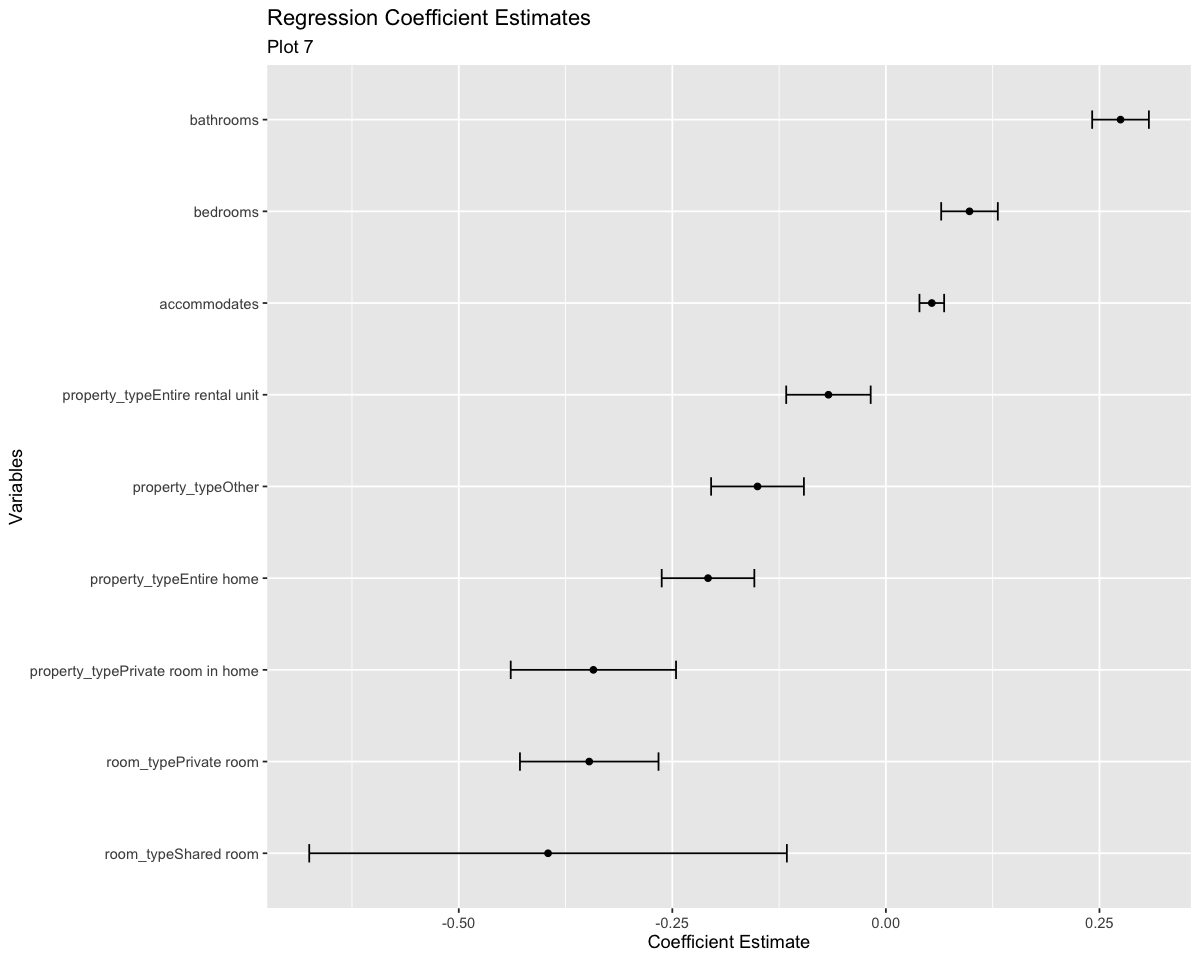

In [22]:
options(repr.plot.width = 10, repr.plot.height = 8)

# Plot a Coefficient Plot of the model
tidy_model <- tidy(airbnb_model, conf.int = TRUE)

p7 <- ggplot(tidy_model %>% filter(term != "(Intercept)"),
       aes(x = estimate, y = reorder(term, estimate))) +
  geom_point() +
  geom_errorbar(aes(xmin = conf.low, xmax = conf.high), height = 0.2) +
  labs(title = "Regression Coefficient Estimates",
       x = "Coefficient Estimate",
       y = "Variables",
       subtitle = "Plot 7")

p7

Some interpretation of the input variables are that all numeric inputs hold a positive relationship with price. `bathrooms` has the most impactful feature with a coefficient of 0.26. The other numerical features `bedrooms` (coefficient: 0.11) and `accommodates` (coefficient: 0.05) also drive price upwards. 

`room_type` and `property_type` being negative coefficients indicate that these features decrease price relative to their baseline categories (`Entire home/apt` and `Entire condo`). Listing a `Private room` (-0.35) or `Shared room` (-0.40) can drastically reduce the expected price compared to the entire apartment. Similarly in the case of the `entire condo` baseline, `Entire rental unit` (-0.06) and `Entire home` (-0.19) have smaller but still negative price differences compared to the baseline

Based on the Adjusted R-squared value, the model yielded an adjusted r-squared of 0.491 meaning that the selected five predictors were able to successfully explain 49.1% of all variance in the log-transformed prices. The outputted F-statistic (494.8, p < 2.2e-16) indicates that this model is highly significant. Every predictor was statistically significant with only `room_typeShared room` and `property_typeEntire` rental unit sitting at the highest p-values but were still well below the standard 0.05 threshold. 

The plot visualizes that `bathrooms` sitting at the far right is clearly the most powerful positive driver with a very tight confidence interval. Meanwhile, the room types and private room predictors sit further left, visually confirming how lack of privacy is a negative factor on a listing's price. The extremely wide confidence interval for the predictor `room_typeShared_room` can likely be due to a smaller sample size of this category in the selected sample from the dataset. 

### 3.2 Interpreting and Evaluating the Results

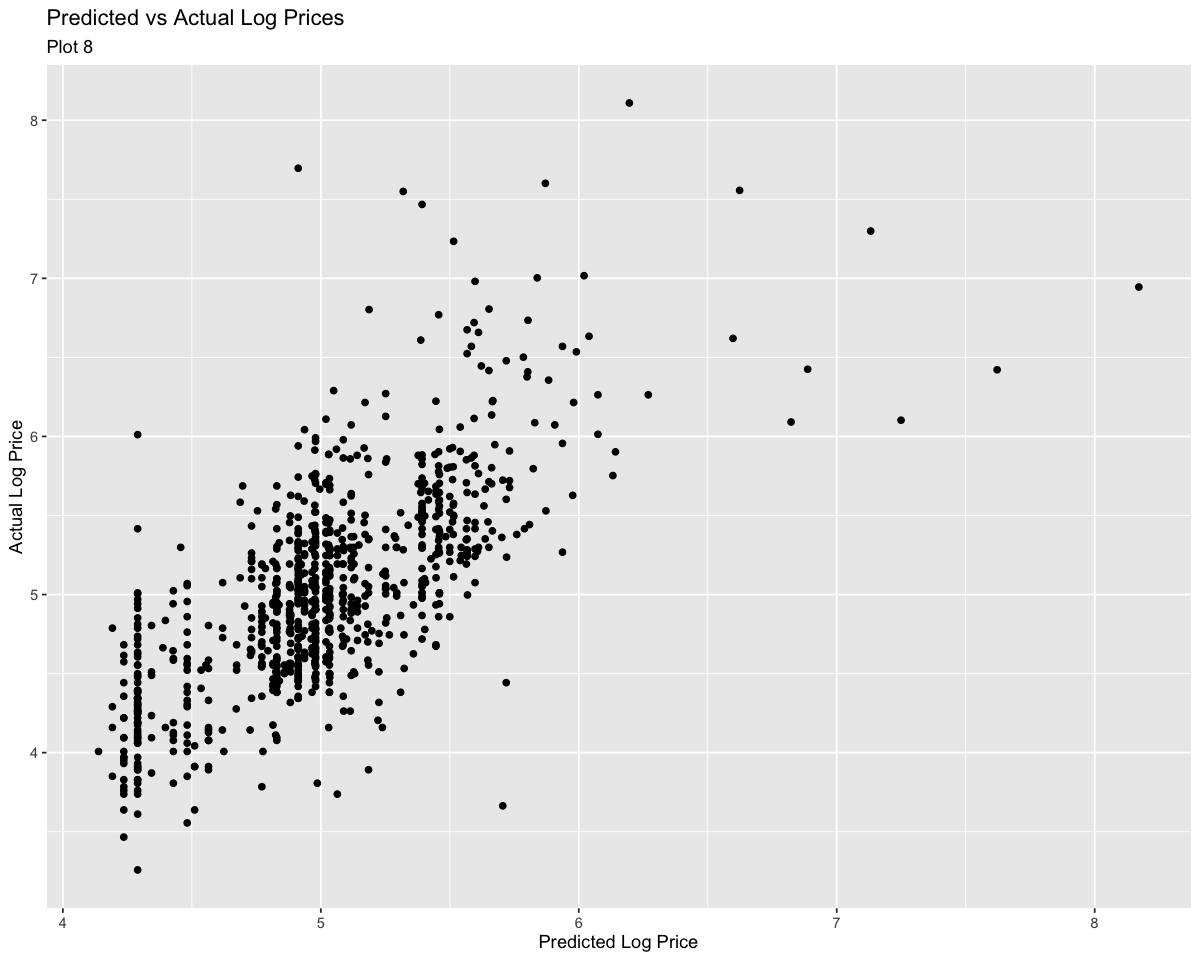

In [30]:
airbnb_residuals <- airbnb_test %>%
    select(log_price) %>%
    mutate(y_hat = predictions,
           residual = log_price - y_hat)

p8 <- airbnb_residuals %>%
    ggplot(aes(x = y_hat, y = log_price)) +
    geom_point() +
    labs(title = "Predicted vs Actual Log Prices",
        x = "Predicted Log Price",
        y = "Actual Log Price",
        subtitle = "Plot 8")

p8

In [31]:
print(paste0("Test RMSE: ", rmse))
print(paste0("Test R-squared: ", r2_test))

[1] "Test RMSE: 0.460254180543878"
[1] "Test R-squared: 0.496507374384843"


The model was evaluated on the test set and achieved an RMSE of 0.46 and an R-squared of 0.497. This means the model explains approximately 49.7% of the variance in log-transformed nightly prices on unseen data. The RMSE of 0.46 on the log scale indicates that on average, the model's predictions deviate from the actual log price by 0.46 units, which translates to a multiplicative error of roughly e<sup>0.46</sup> ≈ 1.58x the actual price in dollar terms.

Overall the model demonstrates moderate predictive performance. It captures nearly half the variability in Airbnb nightly prices using only five features (accommodates, bedrooms, bathrooms, room type, and property type), suggesting these features are meaningful predictors but that other unincluded features likely explain the remaining variance.

### 3.3 Summary

The multiple linear regression model achieved a test RMSE of 0.46 and a test R-squared of 0.497, meaning the model explains approximately 49.7% of the variance in log-transformed nightly prices on unseen data. Physical capacity features were the strongest predictors, with `accommodates` (r=0.58), `bedrooms` (r=0.56), and `bathrooms` (r=0.53) contributing the most to the model's predictive power. Categorical features like `room_type` and `property_type` also improved predictions by capturing privacy and property differences between listings. In contrast, host-centered features such as `review_scores_rating` (r=0.17) and superhost status showed weak predictive value and were excluded from the final model. Overall, the model demonstrates moderate predictive performance using only five features, suggesting that while physical property characteristics are useful predictors of nightly price, other unincluded features such as amenities or location proximity likely account for the remaining variance.

### 3.4 Key Takeaway

A key takeaway is for tourists looking for accommodation in the city. Naturally, the premium sounding name of "superhost" would get people to believe that properties owned by them would be more expensive to stay in. However with these results, budget-conscious tourists can conduct better research into their accommodations by placing less of a consideration on the hosts' status and more on filtering out listings with unneeded bathroom counts. 

Additionally, the model's test R-squared of 0.497 suggests that nearly half of the variance in nightly prices can be predicted using just five easily observable features: room type, property type, number of bathrooms, bedrooms, and capacity. This means tourists can get a reasonable estimate of whether a listing is fairly priced simply by looking at these features, without needing to dig into host history or review scores.

### 3.5 Future Analysis

Future analysis could explore additional features not included in this model, such as listing amenities, proximity to landmarks, or seasonal pricing trends, to improve predictive performance. Additionally, more complex models such as random forests or gradient boosting could be tested to determine whether they yield better predictions than the linear regression model used here. Cross-validation could also be applied to get a more robust estimate of the model's predictive performance.

## 4. References

Belsley, D. A., Kuh, E., & Welsch, R. E. (2005). Regression diagnostics: Identifying influential data and sources of collinearity. John Wiley & Sons.

Draper, N. R., & Smith, H. (1998). Applied regression analysis (Vol. 326). John Wiley & Sons.

Lee, D. K. (2020). Data transformation: a focus on the interpretation. Korean journal of anesthesiology, 73(6), 503-508.

Weissfeld, L. A., & Sereika, S. M. (1991). A multicollinearity diagnostic for generalized linear models. Communications in Statistics-Theory and Methods, 20(4), 1183-1198.